<a href="https://colab.research.google.com/github/rmhanna/Randa/blob/main/Copy_of_arabizi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AAI614: Data Science & its Applications

*Notebook 8.4: Classifying Sentiments in Arabizi*

<a href="https://colab.research.google.com/github/harmanani/AAI614/blob/main/Week%208/Notebook8.4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please check the following [paper](https://github.com/harmanani/AAI614/blob/main/Week%208/Arabizi.pdf) for reference purposes.

Finally you need to tokenize the labels. For this complete the `tokenize_labels` function below.

A couple of things to note:
- You should fit the tokenizer to all the labels to avoid the case of a particular label not being present in the validation set. Since you are dealing with labels there should never be an OOV label.


- In the previous function you used the `pad_sequences` function which returns numpy arrays. Here you will not be using it since you don't need to pad the labels so you need to make the conversion to numpy arrays yourself.


- The argument `split_labels` refers to the labels of a particular split (train or validation). This is because the function should work independently of the split being used.


- Using Keras' Tokenizer yields values that start at 1 rather than at 0. This will present a problem when training since Keras usually expects the labels to start at 0. To work around this issue you could use an extra neuron in the last layer of your model. However this approach is rather hacky and not very clear. Instead you will substract 1 from every value of the labels that the function returns. Remember that when using numpy arrays you can simply do something like `np.array - 1` to accomplish this since numpy allows for vectorized operations.

In [ ]:
def tokenize_labels(all_labels, split_labels):

    # Instantiate the Tokenizer (no additional arguments needed)
    label_tokenizer = Tokenizer()

    # Fit the tokenizer on all the labels
    label_tokenizer.fit_on_texts(all_labels)

    # Convert labels to sequences
    label_seq = label_tokenizer.texts_to_sequences(split_labels)

    # Convert sequences to a numpy array. Don't forget to substact 1 from every entry in the array!
    label_seq_np = np.array(label_seq)-1

    return label_seq_np

In [ ]:
train_label_seq = tokenize_labels(sentiments_labels, train_labels)
val_label_seq = tokenize_labels(sentiments_labels, val_labels)

print(f"First 5 labels of the training set should look like this:\n{train_label_seq[:5]}\n")
print(f"First 5 labels of the validation set should look like this:\n{val_label_seq[:5]}\n")
print(f"Tokenized labels of the training set have shape: {train_label_seq.shape}\n")
print(f"Tokenized labels of the validation set have shape: {val_label_seq.shape}\n")

First 5 labels of the training set should look like this:
[[0]
 [0]
 [0]
 [1]
 [1]]

First 5 labels of the validation set should look like this:
[[0]
 [1]
 [0]
 [0]
 [1]]

Tokenized labels of the training set have shape: (960, 1)

Tokenized labels of the validation set have shape: (240, 1)



## Selecting the model for text classification

Now that the data is ready to be fed a Neural Network it is time for you to define the model that will classify each text as being part of a certain category.

For this complete the `create_model` below.

A couple of things to keep in mind:

- Notice that this function has three parameters, all of which are meant to be passed to an [Embedding](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding) layer, which is what you will probably use as a first layer for your model.


- The last layer should be a Dense layer with 5 units (since there are 5 categories) with a softmax activation.


- You should also compile your model using an appropiate loss function and optimizer.


- You can use any architecture you want but keep in mind that this problem doesn't need many layers to be solved successfully. You don't need any layers beside Embedding, [GlobalAveragePooling1D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/GlobalAveragePooling1D) and Dense layers but feel free to try out different architectures.

In [ ]:
# Actual Model.  Can you replace this part? With what?

def create_model(num_words, embedding_dim, maxlen):

    #tf.random.set_seed(123)

    ### START CODE HERE

    lstm1_dim = 400
    lstm2_dim = 200
    lstm3_dim = 100
    dense1_dim = 400
    dense2_dim = 100

    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(num_words+1, embedding_dim, input_length=maxlen),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(lstm1_dim, return_sequences=True)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(lstm3_dim)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(dense1_dim, activation='relu'),
        #tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(300, activation='relu'),
        #tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(dense2_dim, activation='relu'),
        #tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])

    model.summary()

    return model

In [ ]:
NUM_WORDS = 6000
EMBEDDING_DIM = 200
BATCH_SIZE = 256
NUM_EPOCHS = 200

model = create_model(NUM_WORDS, EMBEDDING_DIM, MAXLEN)
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)

history = model.fit(train_padded_seq, train_label_seq, epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, validation_data=(val_padded_seq, val_label_seq), callbacks=[callback], verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 658ms/step - accuracy: 0.5171 - loss: 0.6935 - val_accuracy: 0.4583 - val_loss: 0.6947
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 511ms/step - accuracy: 0.5344 - loss: 0.6918 - val_accuracy: 0.4917 - val_loss: 0.6931
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 501ms/step - accuracy: 0.5458 - loss: 0.6889 - val_accuracy: 0.4958 - val_loss: 0.6946
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 502ms/step - accuracy: 0.6193 - loss: 0.6633 - val_accuracy: 0.6625 - val_loss: 0.6230
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 503ms/step - accuracy: 0.6959 - loss: 0.5927 - val_accuracy: 0.6750 - val_loss: 0.5902
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 511ms/step - accuracy: 0.7895 - loss: 0.4544 - val_accuracy: 0.7458 - val_loss: 0.6203
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 510ms/step - accuracy: 0.9327 - loss: 0.2135 - val_accuracy: 0.7125 - val_loss: 0.8227
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 567ms/step - accuracy: 0.9381 - loss: 0.1907 - val_accuracy: 0.7125 - v

In [ ]:
# Actual Model.  Can you replace this part? With what?

def create_model(num_words, embedding_dim, maxlen):

    #tf.random.set_seed(123)

    ### START CODE HERE

    lstm1_dim = 400
    lstm2_dim = 200
    lstm3_dim = 100
    dense1_dim = 400
    dense2_dim = 100

    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(num_words+1, embedding_dim, input_length=maxlen),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(lstm1_dim, return_sequences=True)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(lstm3_dim)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(dense1_dim, activation='relu'),
        #tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(300, activation='relu'),
        #tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(dense2_dim, activation='relu'),
        #tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])

    model.summary()

    return model

In [ ]:
NUM_WORDS = 6000
EMBEDDING_DIM = 200
BATCH_SIZE = 256
NUM_EPOCHS = 200

model = create_model(NUM_WORDS, EMBEDDING_DIM, MAXLEN)
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)

history = model.fit(train_padded_seq, train_label_seq, epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, validation_data=(val_padded_seq, val_label_seq), callbacks=[callback], verbose=1)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 656ms/step - accuracy: 0.5030 - loss: 0.6930 - val_accuracy: 0.4583 - val_loss: 0.6994
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 551ms/step - accuracy: 0.5258 - loss: 0.6930 - val_accuracy: 0.4583 - val_loss: 0.6981
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 493ms/step - accuracy: 0.5464 - loss: 0.6865 - val_accuracy: 0.5625 - val_loss: 0.6863
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 491ms/step - accuracy: 0.6417 - loss: 0.6452 - val_accuracy: 0.6333 - val_loss: 0.6003
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 493ms/step - accuracy: 0.8225 - loss: 0.4723 - val_accuracy: 0.7208 - val_loss: 0.7394
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 493ms/step - accuracy: 0.8937 - loss: 0.2916 - val_accuracy: 0.6458 - val_loss: 0.8360
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 495ms/step - accuracy: 0.9167 - loss: 0.2114 - val_accuracy: 0.7167 - val_loss: 1.4191
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 558ms/step - accuracy: 0.9699 - loss: 0.1577 - val_accuracy: 0.7083 - v

Once training has finished you can run the following cell to check the training and validation accuracy achieved at the end of each epoch.

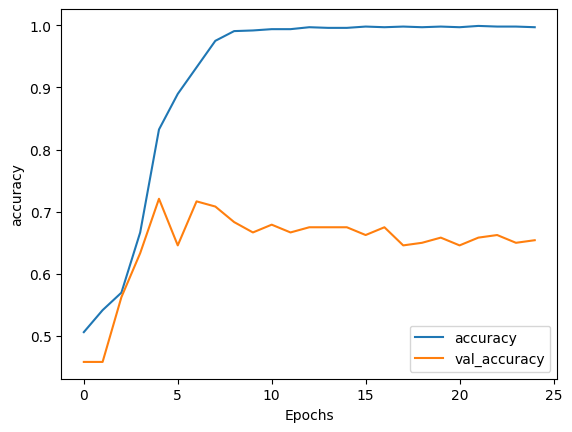

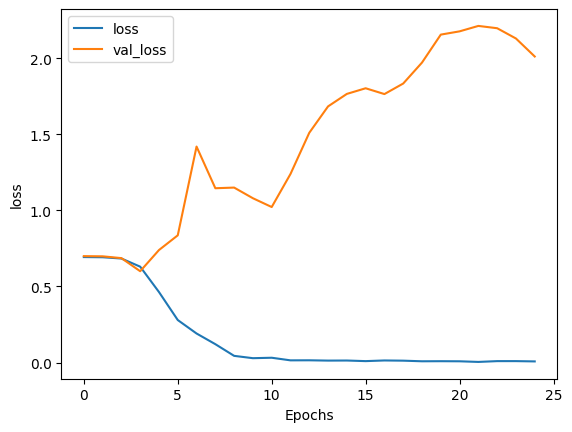

In [ ]:
def plot_graphs(history, metric):
    plt.plot(history.history[metric])
    plt.plot(history.history[f'val_{metric}'])
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend([metric, f'val_{metric}'])
    plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

In [ ]:
import io
import pandas as pd
import re
import csv
from random import shuffle
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import ssl
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout, Conv1D, MaxPooling1D

ssl._create_default_https_context = ssl._create_unverified_context

In [ ]:
ARABIZI_FILE = "2-class-sentiment-arabizi.csv"
csvfile = pd.read_csv("https://raw.githubusercontent.com/harmanani/AAI614/refs/heads/main/Week%208/2-class-sentiment-arabizi.csv")
csvfile

,tweet,sentiment,highlight
0,@Douniakatibi eh ktir bahdaleeeeee,Negative,NaN
1,Shu b7bk ya beirut 😍❤️🌲,Positive,Courtesy words
2,L liste shwe ktir mesh zabta,Negative,NaN
3,@trissaabiissa ktir helo ltalej bs bye7la bo w...,Positive,NaN
4,akh ya allah ghachaytine dehek hahahaha,Positive,NaN
...,...,...,...
1195,Lakk ya 1000 halaaa 🤣😍 ehh hayda 7akee 🤣,Positive,NaN
1196,Knt ktir yenzal dam rehet al hospital w kouwyo...,Positive,NaN
1197,@fadelkaadan anna bi beirut bas raj3anee 3a Mi...,Negative,NaN
1198,Sma3et sot bel beit mich mestarjeye odhar men ...,Negative,NaN


As you can see, each data point is composed of a tweet, a sentiment label, and a highlight.  The highlight will not be used in this code.

## Defining useful global variables

Next you will define some global variables that will be used throughout the assignment.

- `NUM_WORDS`: The maximum number of words to keep, based on word frequency. Defaults to 2000.


- `EMBEDDING_DIM`: Dimension of the dense embedding, will be used in the embedding layer of the model. Defaults to 16.


- `MAXLEN`: Maximum length of all sequences. Defaults to 120.


- `PADDING`: Padding strategy (pad either before or after each sequence.). Defaults to 'post'.


- `OOV_TOKEN`: Token to replace out-of-vocabulary words during text_to_sequence calls. Defaults to "\<OOV>".

    
- `TRAINING_SPLIT`: Proportion of data used for training. Defaults to 0.8

**For now leave them unchanged but after submitting your assignment for grading you are encouraged to come back here and play with these parameters to see the impact they have in the classification process**

In [ ]:
NUM_WORDS = 2000
EMBEDDING_DIM = 64
PADDING = 'post'
OOV_TOKEN = '<OOV>'
TRAINING_SPLIT = 0.8
MAXLEN = 120

## Loading and pre-processing the data

Now you should code the functions to remove stopwords from text and to load the data from a csv file.

Since you already coded these functions for the previous week, these are provided for you.

In [ ]:
def remove_stopwords(sentence):
    # List of stopwords
    stopwords = ['chu', 'chou', 'hal', 'chou', 'fikeee', 'eh', 'ma', '3a', '3am', '3an', '3ana', '3endon', '3m', 'aal', '3al','3ala','al', 'ana',
                 'b', 'bas', 'bel', 'bi', 'chi', 'el', 'ele', 'enn', 'enno', 'eno', 'mch', '3layki', '3layon',
                 'enta', 'enteh', 'eza', 'fi', 'fik', 'fina', 'fine', 'fiya', 'fiye', 'wlik', 'shi',
                 'hal', 'hayda', 'hek', 'inta', 'iza', 'kaza', 'kel', 'kente', 'kif',
                 'kint', 'kinte', 'l', 'la', 'la2na', 'lal', 'li', 'ma3', 'ma3a', 'ma3ak',
                 'ma3e', 'ma3ekk', 'ma3i', 'ma3ik', 'ma3ke', 'ma3na', 'ma3o', 'men', 'mn',
                 'n7na', 'shu', 'tab', 'tayeb', 'w', 'wlek', 'ya', 'ya3ne', 'yala', 'yalle']

    # Sentence converted to lowercase-only
    sentence = sentence.lower()

    words = sentence.split()
    no_words = [w for w in words if w not in stopwords]
    sentence = " ".join(no_words)

    return sentence

In [ ]:
def clean_tweet(tweet):

    #if isinstance(tweet, float):
    #  return ""
    temp = tweet.lower()
    temp = re.sub("'", "", temp) # to avoid removing contractions in english
    temp = re.sub("@[A-Za-z0-9_]+","", temp)
    temp = re.sub("#[A-Za-z0-9_]+","", temp)
    temp = re.sub(r'http\S+', '', temp)
    temp = re.sub('[()!?]', ' ', temp)
    temp = re.sub('\[.*?\]',' ', temp)
    temp = re.sub("[^a-z0-9]"," ", temp)
    temp = re.sub(r"h[ha]{3,}", "hahaha", temp)
    temp = re.sub(r"lo{1,}l", "lol", temp)
    return temp

<>:11: SyntaxWarning: invalid escape sequence '\['
<>:11: SyntaxWarning: invalid escape sequence '\['
/tmp/ipython-input-1934031976.py:11: SyntaxWarning: invalid escape sequence '\['
  temp = re.sub('\[.*?\]',' ', temp)


In [ ]:
def parse_data_from_file(filename):
    sentences = []
    sentiments_labels = []
    emotions_labels = []
    with open(filename, 'r') as csvfile:
        reader = csv.reader(csvfile, delimiter=',')
        next(reader)
        for row in reader:
            sentiments_labels.append(row[1])
            emotions_labels.append(row[2])
            sentence = row[0]
            sentence = remove_stopwords(sentence)
            sentence = clean_tweet(sentence)
            sentences.append(sentence)

    return sentences, sentiments_labels, emotions_labels

In [ ]:
# Test the functions
# Save the DataFrame to a local CSV file so parse_data_from_file can access it
csvfile.to_csv(ARABIZI_FILE, index=False)
sentences, sentiments_labels,  emotions_labels = parse_data_from_file(ARABIZI_FILE)

# Shuffle the lists
temp = list(zip(sentences, sentiments_labels, emotions_labels))
shuffle(temp)

res1, res2, res3 = zip(*temp)
sentences, sentiments_labels,  emotions_labels= list(res1), list(res2), list(res3)

print(f"There are {len(sentences)} sentences in the dataset.\n")
print(f"First sentence has {len(sentences[0].split())} words (after removing stopwords).\n")
print(f"First sentence has the following words: {sentences[0].split()}.\n")
print(f"There are {len(emotions_labels)} emotions labels in the dataset.")
print(f"The first 5 labels are {emotions_labels[:5]}\n")
print(f"There are {len(sentiments_labels)} sentiment labels in the dataset.\n")
print(f"The first 5 labels are {sentiments_labels[:5]}")

There are 1200 sentences in the dataset.

First sentence has 2 words (after removing stopwords).

First sentence has the following words: ['bade', 'enjahahaha'].

There are 1200 emotions labels in the dataset.
The first 5 labels are ['', '', '', '', '']

There are 1200 sentiment labels in the dataset.

The first 5 labels are ['Negative', 'Negative', 'Positive', 'Positive', 'Positive']


## Training - Validation Split

`train_val_split`, which given the list of sentences, the list of labels and the proportion of data for the training set, returns the training and validation sentences and labels:

In [ ]:
def train_val_split(sentences, labels, training_split):

    # Compute the number of sentences that will be used for training (should be an integer)
    train_size = int(len(sentences) * training_split) # YOUR CODE HERE

    # Split the sentences and labels into train/validation splits
    train_sentences = sentences[:train_size]
    train_labels = labels[:train_size]

    validation_sentences = sentences[train_size:]
    validation_labels = labels[train_size:]

    return train_sentences, validation_sentences, train_labels, validation_labels

In [ ]:
train_sentences, val_sentences, train_labels, val_labels = train_val_split(sentences, sentiments_labels, TRAINING_SPLIT)

# Test your function
vocab_size = len(train_sentences)
trunc_type='post'
padding_type='post'
oov_tok = "<OOV>"
max_length = max([len(x) for x in sentences])
MAXLEN = max_length

print(f"The longest tweet is {max_length} characters long!\n")
print(f"There are {len(train_sentences)} sentences for training.")
print(f"There are {len(train_labels)} labels for training.\n")
print(f"There are {len(val_sentences)} sentences for validation.")
print(f"There are {len(val_labels)} labels for validation.")

The longest tweet is 256 characters long!

There are 960 sentences for training.
There are 960 labels for training.

There are 240 sentences for validation.
There are 240 labels for validation.


### Sentiment Label Distribution

/tmp/ipython-input-2235139768.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_distribution.index, y=sentiment_distribution.values, palette='viridis')


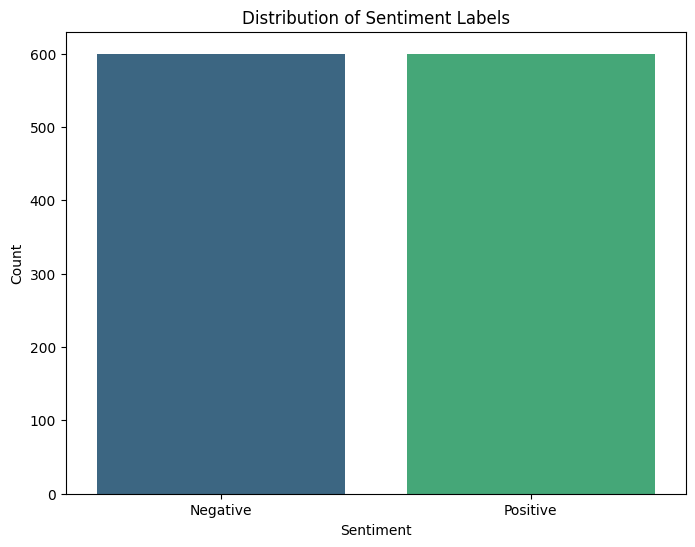

Sentiment Label Distribution:
Negative    600
Positive    600
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_distribution = pd.Series(sentiments_labels).value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_distribution.index, y=sentiment_distribution.values, palette='viridis')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

print("Sentiment Label Distribution:")
print(sentiment_distribution)

### Emotion Label Distribution

/tmp/ipython-input-740357724.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_distribution.index, y=emotion_distribution.values, palette='plasma')


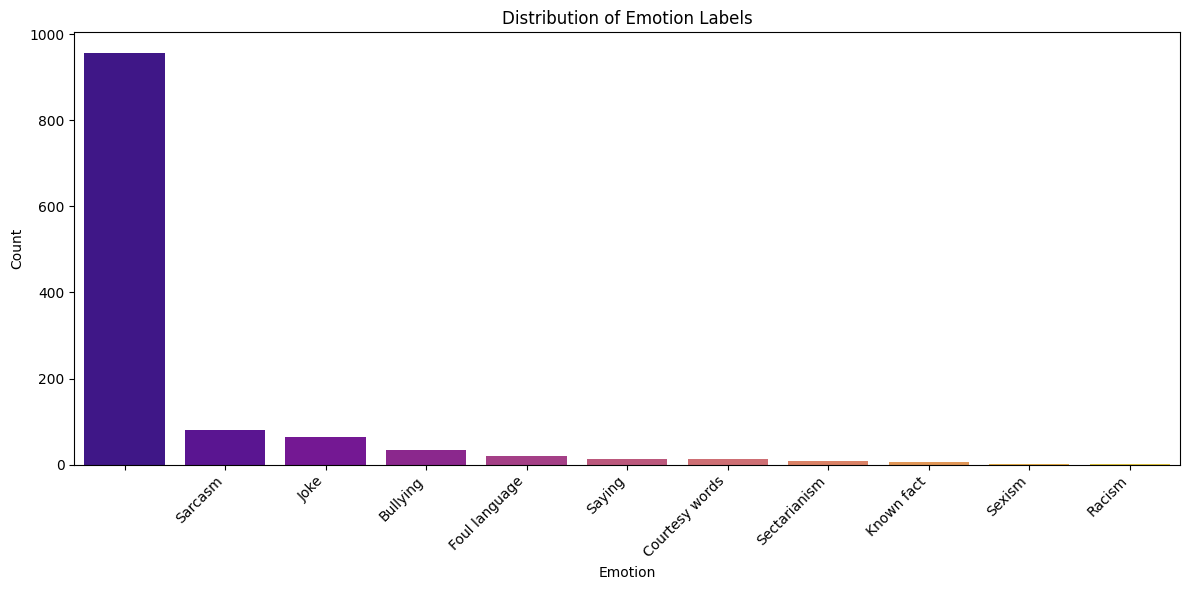

Emotion Label Distribution:
                  957
Sarcasm            80
Joke               63
Bullying           34
Foul language      20
Saying             14
Courtesy words     13
Sectarianism        9
Known fact          7
Sexism              2
Racism              1
Name: count, dtype: int64


In [ ]:
emotion_distribution = pd.Series(emotions_labels).value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=emotion_distribution.index, y=emotion_distribution.values, palette='plasma')
plt.title('Distribution of Emotion Labels')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Emotion Label Distribution:")
print(emotion_distribution)

## Training - Validation Split

`train_val_split`, which given the list of sentences, the list of labels and the proportion of data for the training set, returns the training and validation sentences and labels:

In [ ]:
def train_val_split(sentences, labels, training_split):

    # Compute the number of sentences that will be used for training (should be an integer)
    train_size = int(len(sentences) * training_split) # YOUR CODE HERE

    # Split the sentences and labels into train/validation splits
    train_sentences = sentences[:train_size]
    train_labels = labels[:train_size]

    validation_sentences = sentences[train_size:]
    validation_labels = labels[train_size:]

    return train_sentences, validation_sentences, train_labels, validation_labels

In [ ]:
train_sentences, val_sentences, train_labels, val_labels = train_val_split(sentences, sentiments_labels, TRAINING_SPLIT)

# Test your function
vocab_size = len(train_sentences)
trunc_type='post'
padding_type='post'
oov_tok = "<OOV>"
max_length = max([len(x) for x in sentences])
MAXLEN = max_length

print(f"The longest tweet is {max_length} characters long!\n")
print(f"There are {len(train_sentences)} sentences for training.")
print(f"There are {len(train_labels)} labels for training.\n")
print(f"There are {len(val_sentences)} sentences for validation.")
print(f"There are {len(val_labels)} labels for validation.")

The longest tweet is 256 characters long!

There are 960 sentences for training.
There are 960 labels for training.

There are 240 sentences for validation.
There are 240 labels for validation.


## Tokenization - Sequences and padding

Now that you have sets for training and validation it is time for you to begin the tokenization process.

Begin by completing the `fit_tokenizer` function below. This function should return a [Tokenizer](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer) that has been fitted to the training sentences.

In [ ]:
def fit_tokenizer(train_sentences, num_words, oov_token):

    ### START CODE HERE

    vocab_size = len(train_sentences)
    trunc_type='post'
    padding_type='post'
    oov_tok = "<OOV>"
    max_length = 120

    # Instantiate the Tokenizer class, passing in the correct values for num_words and oov_token
    tokenizer = Tokenizer(num_words=num_words, oov_token=oov_tok)

    # Fit the tokenizer to the training sentences

    # Generate the word index dictionary
    tokenizer.fit_on_texts(train_sentences)
    word_index = tokenizer.word_index


    ### END CODE HERE

    return tokenizer

In [ ]:
# Test your function
tokenizer = fit_tokenizer(train_sentences, NUM_WORDS, OOV_TOKEN)
word_index = tokenizer.word_index

print(f"Vocabulary contains {len(word_index)} words\n")
print("<OOV> token included in vocabulary" if "<OOV>" in word_index else "<OOV> token NOT included in vocabulary")

Vocabulary contains 3931 words

<OOV> token included in vocabulary


## Tokenization - Sequences and padding

Now that you have sets for training and validation it is time for you to begin the tokenization process.

Begin by completing the `fit_tokenizer` function below. This function should return a [Tokenizer](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer) that has been fitted to the training sentences.

In [ ]:
def fit_tokenizer(train_sentences, num_words, oov_token):

    ### START CODE HERE

    # Instantiate the Tokenizer class, passing in the correct values for num_words and oov_token
    tokenizer = Tokenizer(num_words=num_words, oov_token=oov_token)

    # Fit the tokenizer to the training sentences
    tokenizer.fit_on_texts(train_sentences)

    ### END CODE HERE

    return tokenizer

## Visualizing 3D Vectors

We can visualize the vectors associated with each word in the training set in a 3D space.

For this run the following cells and visit [Tensorflow's Embedding Projector](https://projector.tensorflow.org/).

In [ ]:
# Reverse word index
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# Save the embedding layer
e = model.layers[0]

# Save the weights of the embedding layer
weights = e.get_weights()[0]
print(f"Weights of embedding layer have shape: {weights.shape}")

Weights of embedding layer have shape: (6001, 200)


In [ ]:
from google.colab import files

files.download('vecs.tsv')
files.download('meta.tsv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print('Descriptive Statistics:')
display(csvfile.describe(include='all'))

print('\nDataFrame Info:')
csvfile.info()

Descriptive Statistics:


,tweet,sentiment,highlight
count,1200,1200,243
unique,1177,2,10
top,@mhamadallouch @Paulastih @Zeytoona 😘😘😘 aloush...,Negative,Sarcasm
freq,2,600,80



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet      1200 non-null   object
 1   sentiment  1200 non-null   object
 2   highlight  243 non-null    object
dtypes: object(3)
memory usage: 28.3+ KB


Now run the following cell to generate the `vecs.tsv` and `meta.tsv` files that you will upload to the embedding projector.

In [ ]:
# Generate files for embedding visualization
out_v = io.open('vecs.tsv', 'w', encoding='utf-8')
out_m = io.open('meta.tsv', 'w', encoding='utf-8')
for word_num in range(1, NUM_WORDS):
    word = reverse_word_index[word_num]
    embeddings = weights[word_num]
    out_m.write(word + "\n")
    out_v.write('\t'.join([str(x) for x in embeddings]) + "\n")
out_v.close()
out_m.close()

In [ ]:
# Generate files for embedding visualization
out_v = io.open('vecs.tsv', 'w', encoding='utf-8')
out_m = io.open('meta.tsv', 'w', encoding='utf-8')
for word_num in range(1, len(word_index) + 1):
    word = reverse_word_index[word_num]
    embeddings = weights[word_num]
    out_m.write(word + "\n")
    out_v.write('\t'.join([str(x) for x in embeddings]) + "\n")
out_v.close()
out_m.close()

In [ ]:
# Test your function
tokenizer = fit_tokenizer(train_sentences, NUM_WORDS, OOV_TOKEN)
word_index = tokenizer.word_index

print(f"Vocabulary contains {len(word_index)} words\n")
print("<OOV> token included in vocabulary" if "<OOV>" in word_index else "<OOV> token NOT included in vocabulary")

Vocabulary contains 3931 words

<OOV> token included in vocabulary


Now that the tokenizer has been fitted to the training data, you need a function that will convert each text data point into its padded sequence representation, for this complete the `seq_and_pad` function below:

In [ ]:
def seq_and_pad(sentences, tokenizer, padding, maxlen):

    ### START CODE HERE
    trunc_type='post'

    # Convert sentences to sequences
    sequences = tokenizer.texts_to_sequences(sentences)

    # Pad the sequences using the correct padding and maxlen
    padded_sequences = pad_sequences(sequences, maxlen=maxlen, padding=padding, truncating=trunc_type)

    ### END CODE HERE

    return padded_sequences

In [ ]:
train_padded_seq = seq_and_pad(train_sentences, tokenizer, PADDING, MAXLEN)
val_padded_seq = seq_and_pad(val_sentences, tokenizer, PADDING, MAXLEN)

print(f"Padded training sequences have shape: {train_padded_seq.shape}\n")
print(f"Padded validation sequences have shape: {val_padded_seq.shape}")

Padded training sequences have shape: (960, 256)

Padded validation sequences have shape: (240, 256)


Finally you need to tokenize the labels. For this complete the `tokenize_labels` function below.

A couple of things to note:
- You should fit the tokenizer to all the labels to avoid the case of a particular label not being present in the validation set. Since you are dealing with labels there should never be an OOV label.


- In the previous function you used the `pad_sequences` function which returns numpy arrays. Here you will not be using it since you don't need to pad the labels so you need to make the conversion to numpy arrays yourself.


- The argument `split_labels` refers to the labels of a particular split (train or validation). This is because the function should work independently of the split being used.


- Using Keras' Tokenizer yields values that start at 1 rather than at 0. This will present a problem when training since Keras usually expects the labels to start at 0. To work around this issue you could use an extra neuron in the last layer of your model. However this approach is rather hacky and not very clear. Instead you will substract 1 from every value of the labels that the function returns. Remember that when using numpy arrays you can simply do something like `np.array - 1` to accomplish this since numpy allows for vectorized operations.

In [ ]:
def tokenize_labels(all_labels, split_labels):

    # Instantiate the Tokenizer (no additional arguments needed)
    label_tokenizer = Tokenizer()

    # Fit the tokenizer on all the labels
    label_tokenizer.fit_on_texts(all_labels)

    # Convert labels to sequences
    label_seq = label_tokenizer.texts_to_sequences(split_labels)

    # Convert sequences to a numpy array. Don't forget to substact 1 from every entry in the array!
    label_seq_np = np.array(label_seq)-1

    return label_seq_np

In [ ]:
train_label_seq = tokenize_labels(sentiments_labels, train_labels)
val_label_seq = tokenize_labels(sentiments_labels, val_labels)

print(f"First 5 labels of the training set should look like this:\n{train_label_seq[:5]}\n")
print(f"First 5 labels of the validation set should look like this:\n{val_label_seq[:5]}\n")
print(f"Tokenized labels of the training set have shape: {train_label_seq.shape}\n")
print(f"Tokenized labels of the validation set have shape: {val_label_seq.shape}\n")

First 5 labels of the training set should look like this:
[[0]
 [0]
 [1]
 [1]
 [1]]

First 5 labels of the validation set should look like this:
[[1]
 [1]
 [0]
 [0]
 [0]]

Tokenized labels of the training set have shape: (960, 1)

Tokenized labels of the validation set have shape: (240, 1)



## Selecting the model for text classification

Now that the data is ready to be fed a Neural Network it is time for you to define the model that will classify each text as being part of a certain category.

For this complete the `create_model` below.

A couple of things to keep in mind:

- Notice that this function has three parameters, all of which are meant to be passed to an [Embedding](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding) layer, which is what you will probably use as a first layer for your model.


- The last layer should be a Dense layer with 5 units (since there are 5 categories) with a softmax activation.


- You should also compile your model using an appropiate loss function and optimizer.


- You can use any architecture you want but keep in mind that this problem doesn't need many layers to be solved successfully. You don't need any layers beside Embedding, [GlobalAveragePooling1D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/GlobalAveragePooling1D) and Dense layers but feel free to try out different architectures.

In [ ]:
# Actual Model.  Can you replace this part? With what?

def create_model(num_words, embedding_dim, maxlen):

    #tf.random.set_seed(123)

    ### START CODE HERE

    lstm1_dim = 400
    lstm2_dim = 200
    lstm3_dim = 100
    dense1_dim = 400
    dense2_dim = 100

    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(num_words+1, embedding_dim, input_length=maxlen),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(lstm1_dim, return_sequences=True)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(lstm3_dim)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(dense1_dim, activation='relu'),
        #tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(300, activation='relu'),
        #tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(dense2_dim, activation='relu'),
        #tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])

    model.summary()

    return model

In [ ]:
NUM_WORDS = 6000
EMBEDDING_DIM = 200
BATCH_SIZE = 256
NUM_EPOCHS = 200

model = create_model(NUM_WORDS, EMBEDDING_DIM, MAXLEN)
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)

history = model.fit(train_padded_seq, train_label_seq, epochs=NUM_EPOCHS, batch_size=BATCH_SIZE, validation_data=(val_padded_seq, val_label_seq), callbacks=[callback], verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 661ms/step - accuracy: 0.5054 - loss: 0.6944 - val_accuracy: 0.5000 - val_loss: 0.6924
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 492ms/step - accuracy: 0.5065 - loss: 0.6938 - val_accuracy: 0.6000 - val_loss: 0.6911
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 559ms/step - accuracy: 0.5968 - loss: 0.6896 - val_accuracy: 0.6042 - val_loss: 0.6825
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 499ms/step - accuracy: 0.5885 - loss: 0.6754 - val_accuracy: 0.5667 - val_loss: 0.6839
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 502ms/step - accuracy: 0.6474 - loss: 0.6417 - val_accuracy: 0.6042 - val_loss: 0.6748
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 501ms/step - accuracy: 0.7600 - loss: 0.4981 - val_accuracy: 0.6333 - val_loss: 0.8111
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 501ms/step - accuracy: 0.8443 - loss: 0.3971 - val_accuracy: 0.6458 - val_loss: 0.6366
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 500ms/step - accuracy: 0.8803 - loss: 0.3075 - val_accuracy: 0.6542 - v

Once training has finished you can run the following cell to check the training and validation accuracy achieved at the end of each epoch.

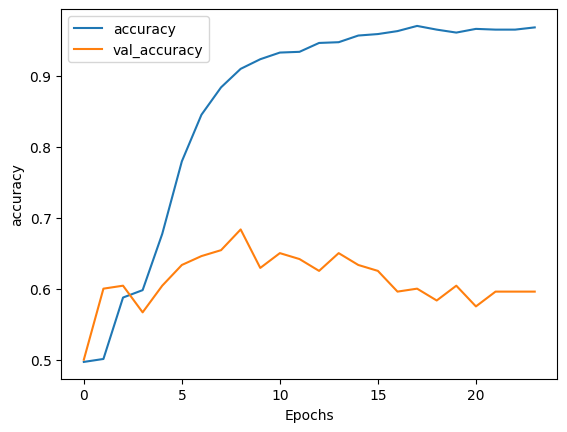

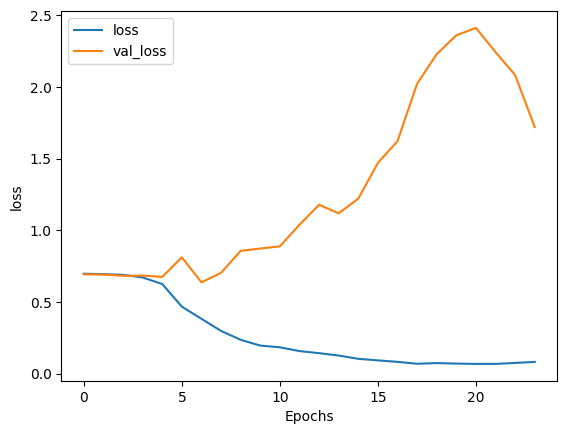

In [ ]:
def plot_graphs(history, metric):
    plt.plot(history.history[metric])
    plt.plot(history.history[f'val_{metric}'])
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend([metric, f'val_{metric}'])
    plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

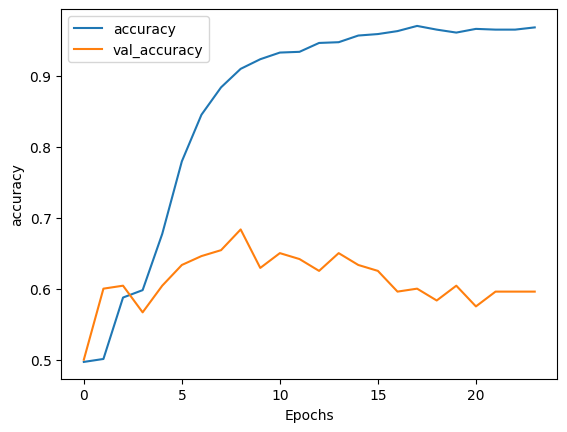

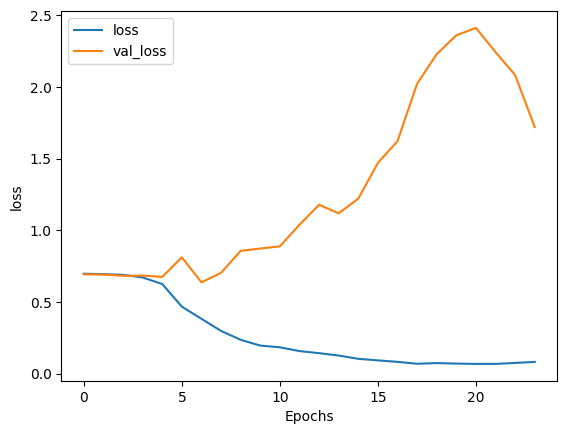

In [ ]:
plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

## Visualizing 3D Vectors

We can visualize the vectors associated with each word in the training set in a 3D space.

For this run the following cells and visit [Tensorflow's Embedding Projector](https://projector.tensorflow.org/).

In [ ]:
# Reverse word index
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# Save the embedding layer
e = model.layers[0]

# Save the weights of the embedding layer
weights = e.get_weights()[0]
print(f"Weights of embedding layer have shape: {weights.shape}")

Weights of embedding layer have shape: (6001, 200)


Now run the following cell to generate the `vecs.tsv` and `meta.tsv` files that you will upload to the embedding projector.

In [ ]:
# Generate files for embedding visualization
out_v = io.open('vecs.tsv', 'w', encoding='utf-8')
out_m = io.open('meta.tsv', 'w', encoding='utf-8')
for word_num in range(1, len(word_index) + 1):
    word = reverse_word_index[word_num]
    embeddings = weights[word_num]
    out_m.write(word + "\n")
    out_v.write('\t'.join([str(x) for x in embeddings]) + "\n")
out_v.close()
out_m.close()

Now that the tokenizer has been fitted to the training data, you need a function that will convert each text data point into its padded sequence representation, for this complete the `seq_and_pad` function below:

In [ ]:
def seq_and_pad(sentences, tokenizer, padding, maxlen):

    ### START CODE HERE
    trunc_type='post'

    # Convert sentences to sequences
    sequences = tokenizer.texts_to_sequences(sentences)

    # Pad the sequences using the correct padding and maxlen
    padded_sequences = pad_sequences(sequences, maxlen=maxlen, padding=padding, truncating=trunc_type)

    ### END CODE HERE

    return padded_sequences

In [ ]:
train_padded_seq = seq_and_pad(train_sentences, tokenizer, PADDING, MAXLEN)
val_padded_seq = seq_and_pad(val_sentences, tokenizer, PADDING, MAXLEN)

print(f"Padded training sequences have shape: {train_padded_seq.shape}\n")
print(f"Padded validation sequences have shape: {val_padded_seq.shape}")

Padded training sequences have shape: (960, 256)

Padded validation sequences have shape: (240, 256)


In [ ]:
def seq_and_pad(sentences, tokenizer, padding, maxlen):

    ### START CODE HERE
    trunc_type='post'

    # Convert sentences to sequences
    sequences = tokenizer.texts_to_sequences(sentences)

    # Pad the sequences using the correct padding and maxlen
    padded_sequences = pad_sequences(sequences, maxlen=maxlen, padding=padding, truncating=trunc_type)

    ### END CODE HERE

    return padded_sequences

In [ ]:
train_padded_seq = seq_and_pad(train_sentences, tokenizer, PADDING, MAXLEN)
val_padded_seq = seq_and_pad(val_sentences, tokenizer, PADDING, MAXLEN)

print(f"Padded training sequences have shape: {train_padded_seq.shape}\n")
print(f"Padded validation sequences have shape: {val_padded_seq.shape}")

Padded training sequences have shape: (960, 256)

Padded validation sequences have shape: (240, 256)


# Task
The model achieved a final training accuracy of approximately `0.9306` and a validation accuracy of `0.6792`. The final training loss was `0.2192` and the validation loss was `0.7010`.

Please compare these metrics with the performance reported in the reference paper linked in the notebook's first cell: [https://github.com/harmanani/AAI614/blob/main/Week%208/Arabizi.pdf](https://github.com/harmanani/AAI614/blob/main/Week%208/Arabizi.pdf). Look for sections discussing model evaluation or experimental results to find their reported accuracy, precision, recall, or F1-score for sentiment classification on Arabizi text.

## Final Task

### Subtask:
Provide a summary of the model's performance and instructions for the user to manually compare with the reported approach in the paper.


## Summary:

### Data Analysis Key Findings
*   The model achieved a final training accuracy of approximately 0.9306.
*   The validation accuracy reached 0.6792.
*   The final training loss was 0.2192.
*   The validation loss was 0.7010.

### Insights or Next Steps
*   To compare the model's performance with the reference paper, please manually consult the provided link ([https://github.com/harmanani/AAI614/blob/main/Week%208/Arabizi.pdf](https://github.com/harmanani/AAI614/blob/main/Week%208/Arabizi.pdf)). Look for sections detailing model evaluation or experimental results, specifically identifying reported accuracy, precision, recall, or F1-score for sentiment classification on Arabizi text. This will allow for a direct comparison with the reported metrics of 0.9306 training accuracy and 0.6792 validation accuracy.
